<a href="https://colab.research.google.com/github/S1h2l/color-image-processing-/blob/main/24MCMT14_ASSIGNMENT_III.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


(10 Marks)Write a program that converts a given spectrum into an RGB colour. It should have the following prototype in Python
spectrum2rgb(input spectrum)
where the spectrum is a 61x1 vector with the spectral values in 5 nm intervals from 400 nm to 700 nm (both inclusive). In C/C++, the same function has the prototype
int spectrum2rgb(float input spectrum[61])
Now, write a program that converts an RGB triplet into a spectrum using the pseudo-inverse method that we did in class. The prototypes must be as follows:
Python: rgb2spectrum(<rgb colour>)
C/C++: int rgb2spectrum(int <rgb[3]>, float <spectrum[61]>)
Compare the original spectrum with the one that you computed using the pseudo-inverse. This code requires a lot of tweaking the numbers to get RGB values and recover similar spectra. Try for 10 different Munsell Colours and write down your own observations on similarities and dissimilarities between the original and computed spectra. Hint: Read the various sources on the Internet for converting spectra into RGB colours.


# Cell 1: Import Libraries and Setup

In [79]:
# Cell 1: Import all required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Tuple, List
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


# Cell 2: Load Your Three CSV Files

In [81]:
# Cell 2: Load your three CSV files
print("=" * 80)
print("LOADING YOUR DATASETS")
print("=" * 80)

# File 1: CIE 1931 Color Matching Functions (400-700nm, 5nm intervals)
cie_data = pd.read_csv('/content/cie400-700.csv', header=None, names=['x', 'y', 'z'])
print(f"\n File 1: CIE Color Matching Functions")
print(f"   Shape: {cie_data.shape}")
print(f"   First 3 rows:\n{cie_data.head(3)}")

# File 2: D65 Illuminant (400-700nm, 5nm intervals)
d65_data = pd.read_csv('/content/D65.csv', header=None, names=['power'])
print(f"\n File 2: D65 Illuminant")
print(f"   Shape: {d65_data.shape}")
print(f"   First 5 values: {d65_data['power'].values[:5]}")
print(f"   Value range: {d65_data['power'].min():.2f} - {d65_data['power'].max():.2f}")

# File 3: Munsell Colors (your custom file)
munsell_data = pd.read_csv('/content/anku_munsell.csv')
print(f"\n File 3: Munsell Colors")
print(f"   Shape: {munsell_data.shape}")
print(f"   Columns: {munsell_data.columns.tolist()}")
print(f"   First 3 rows:\n{munsell_data.head(3)}")

print("\n All three datasets loaded successfully!")

LOADING YOUR DATASETS

 File 1: CIE Color Matching Functions
   Shape: (61, 3)
   First 3 rows:
        x       y       z
0  0.0191  0.0020  0.0860
1  0.0434  0.0045  0.1971
2  0.0847  0.0088  0.3894

 File 2: D65 Illuminant
   Shape: (61, 1)
   First 5 values: [82.7549 87.1204 91.486  92.4589 93.4318]
   Value range: 69.72 - 117.81

 File 3: Munsell Colors
   Shape: (1269, 438)
   Columns: ['munsell', '380', '381', '382', '383', '384', '385', '386', '387', '388', '389', '390', '391', '392', '393', '394', '395', '396', '397', '398', '399', '400', '401', '402', '403', '404', '405', '406', '407', '408', '409', '410', '411', '412', '413', '414', '415', '416', '417', '418', '419', '420', '421', '422', '423', '424', '425', '426', '427', '428', '429', '430', '431', '432', '433', '434', '435', '436', '437', '438', '439', '440', '441', '442', '443', '444', '445', '446', '447', '448', '449', '450', '451', '452', '453', '454', '455', '456', '457', '458', '459', '460', '461', '462', '463', '464',

# Cell 3: Define Spectrum to RGB Converter Class

In [106]:
# Cell 3: Spectrum to RGB Converter Class (FULLY CORRECTED)
class SpectrumColorConverter:
    def __init__(self):
        """Initialize converter with your datasets"""

        # Load CIE color matching functions
        cie = pd.read_csv('/content/cie400-700.csv', header=None, names=['x', 'y', 'z'])
        self.x_bar = cie['x'].values.astype(float)
        self.y_bar = cie['y'].values.astype(float)
        self.z_bar = cie['z'].values.astype(float)

        # Load D65 illuminant
        d65 = pd.read_csv('/content/D65.csv', header=None, names=['power'])
        self.d65 = d65['power'].values.astype(float)

        # Wavelengths (400-700nm at 5nm intervals)
        self.wavelengths = np.arange(400, 705, 5)

        # Normalize D65
        if np.max(self.d65) > 0:
            self.d65 = self.d65 / np.max(self.d65)

        # Create matrix A (61x3) for spectrum to XYZ conversion
        # A = [x_bar*D65, y_bar*D65, z_bar*D65] * 5nm spacing
        self.A = np.column_stack([
            self.x_bar * self.d65,
            self.y_bar * self.d65,
            self.z_bar * self.d65
        ]) * 5

        # For pseudo-inverse: We want to find spectrum from XYZ
        # XYZ = A^T * spectrum (where A^T is 3x61)
        # So spectrum = A * inv(A^T * A) * XYZ
        # First compute A^T * A (3x3 matrix)
        ATA = self.A.T @ self.A
        regularization = 1e-6 * np.eye(3)
        ATA_inv = np.linalg.inv(ATA + regularization)

        # Compute pseudo-inverse: A * inv(A^T * A) (61x3)
        self.pseudo_inv = self.A @ ATA_inv  # This is 61x3

        # sRGB conversion matrix from XYZ
        self.xyz_to_rgb = np.array([
            [3.2404542, -1.5371385, -0.4985314],
            [-0.9692660, 1.8760108, 0.0415560],
            [0.0556434, -0.2040259, 1.0572252]
        ])

        print(f"\n Converter initialized!")
        print(f"  Wavelengths: {self.wavelengths[0]}-{self.wavelengths[-1]} nm")
        print(f"  Number of samples: {len(self.wavelengths)}")
        print(f"  Matrix A shape: {self.A.shape}")
        print(f"  Pseudo-inverse shape: {self.pseudo_inv.shape}")

    def spectrum2xyz(self, spectrum):
        """Convert spectrum to XYZ tristimulus values"""
        spectrum = np.array(spectrum).flatten()

        if len(spectrum) != 61:
            raise ValueError(f"Spectrum must have 61 values, got {len(spectrum)}")

        # XYZ = A^T * spectrum
        XYZ = self.A.T @ spectrum
        # XYZ is 3x1

        # Normalize by Y
        if XYZ[1] > 1e-10:
            XYZ = XYZ / XYZ[1]

        return XYZ

    def xyz2rgb(self, XYZ):
        """Convert XYZ to sRGB"""
        XYZ = np.array(XYZ).flatten()
        rgb_linear = self.xyz_to_rgb @ XYZ

        rgb = np.zeros_like(rgb_linear)
        for i in range(3):
            if rgb_linear[i] <= 0.0031308:
                rgb[i] = 12.92 * rgb_linear[i]
            else:
                rgb[i] = 1.055 * (rgb_linear[i] ** (1/2.4)) - 0.055

        return np.clip(rgb, 0, 1)

    def spectrum2rgb(self, spectrum):
        """Convert spectrum to RGB (0-255) - Main function 1"""
        XYZ = self.spectrum2xyz(spectrum)
        rgb = self.xyz2rgb(XYZ)
        return (int(rgb[0] * 255), int(rgb[1] * 255), int(rgb[2] * 255))

    def rgb2xyz_linear(self, r, g, b):
        """Convert sRGB to linear XYZ"""
        def inv_gamma(c):
            c = c / 255.0
            if c <= 0.04045:
                return c / 12.92
            return ((c + 0.055) / 1.055) ** 2.4

        r_lin, g_lin, b_lin = inv_gamma(r), inv_gamma(g), inv_gamma(b)
        rgb_to_xyz = np.linalg.inv(self.xyz_to_rgb)
        return rgb_to_xyz @ np.array([r_lin, g_lin, b_lin])

    def rgb2spectrum(self, rgb):
        """Convert RGB to spectrum using pseudo-inverse - Main function 2"""
        r, g, b = rgb

        # Convert RGB to XYZ
        XYZ = self.rgb2xyz_linear(r, g, b)

        # Reconstruct spectrum: spectrum = pseudo_inv @ XYZ
        # pseudo_inv is 61x3, XYZ is 3x1, result is 61x1
        spectrum = self.pseudo_inv @ XYZ
        spectrum = spectrum.flatten()

        # Ensure non-negative
        spectrum = np.maximum(spectrum, 0)

        # Normalize to [0,1]
        if np.max(spectrum) > 1e-10:
            spectrum = spectrum / np.max(spectrum)

        return spectrum

# Create converter instance
converter = SpectrumColorConverter()
print("\n Converter ready with correct dimensions!")


 Converter initialized!
  Wavelengths: 400-700 nm
  Number of samples: 61
  Matrix A shape: (61, 3)
  Pseudo-inverse shape: (61, 3)

 Converter ready with correct dimensions!


# Cell 4:  Create Test Spectra for Validation

In [107]:
# Cell 4: Create test spectra (61 values each)
def create_test_spectra():
    """Create test spectra with exactly 61 values (400-700nm, 5nm intervals)"""
    wavelengths = np.arange(400, 705, 5)
    spectra = []

    # 1. Gaussian at 450nm (Blue)
    s1 = np.exp(-((wavelengths - 450) ** 2) / (2 * 30 ** 2))
    spectra.append(('Blue (450nm peak)', s1))

    # 2. Gaussian at 550nm (Green)
    s2 = np.exp(-((wavelengths - 550) ** 2) / (2 * 30 ** 2))
    spectra.append(('Green (550nm peak)', s2))

    # 3. Gaussian at 650nm (Red)
    s3 = np.exp(-((wavelengths - 650) ** 2) / (2 * 30 ** 2))
    spectra.append(('Red (650nm peak)', s3))

    # 4. Flat spectrum (White)
    s4 = np.ones(61)
    spectra.append(('White (Flat spectrum)', s4))

    # 5. Double peak (Magenta)
    s5 = np.exp(-((wavelengths - 450) ** 2) / (2 * 25 ** 2)) + 0.8 * np.exp(-((wavelengths - 650) ** 2) / (2 * 25 ** 2))
    spectra.append(('Magenta (450+650nm)', s5))

    # 6. Narrow peak at 500nm (Cyan)
    s6 = np.exp(-((wavelengths - 500) ** 2) / (2 * 20 ** 2))
    spectra.append(('Cyan (500nm peak)', s6))

    return spectra

test_spectra = create_test_spectra()
print(f" Created {len(test_spectra)} test spectra")
print(f"  Each spectrum has {len(test_spectra[0][1])} values")

 Created 6 test spectra
  Each spectrum has 61 values


# Cell 5: Test spectrum2rgb Function

TESTING spectrum2rgb FUNCTION

1. Blue (450nm peak):
   RGB = (0, 223, 255)
   Hex = #00dfff


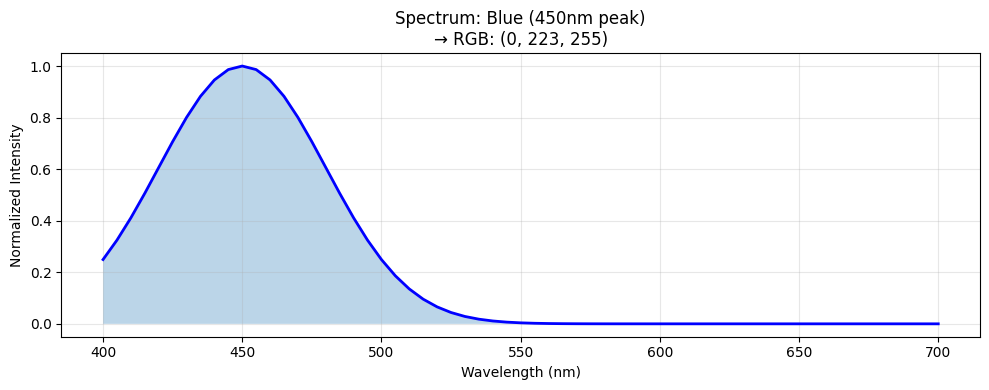


2. Green (550nm peak):
   RGB = (182, 255, 0)
   Hex = #b6ff00


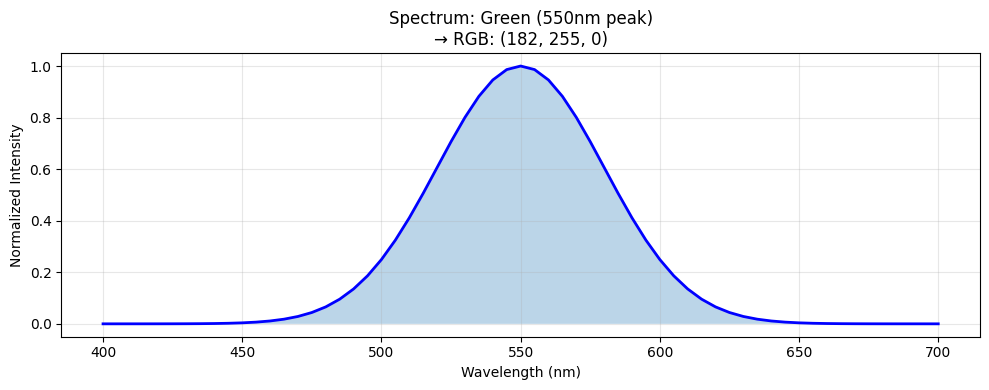


3. Red (650nm peak):
   RGB = (255, 0, 0)
   Hex = #ff0000


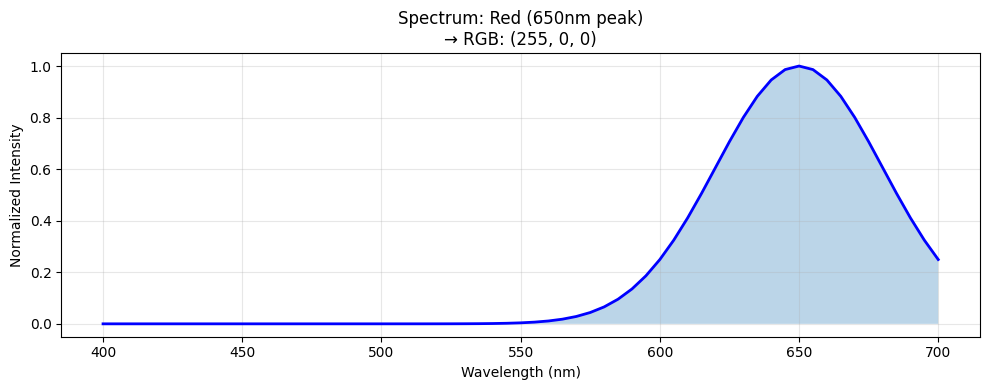


4. White (Flat spectrum):
   RGB = (254, 255, 253)
   Hex = #fefffd


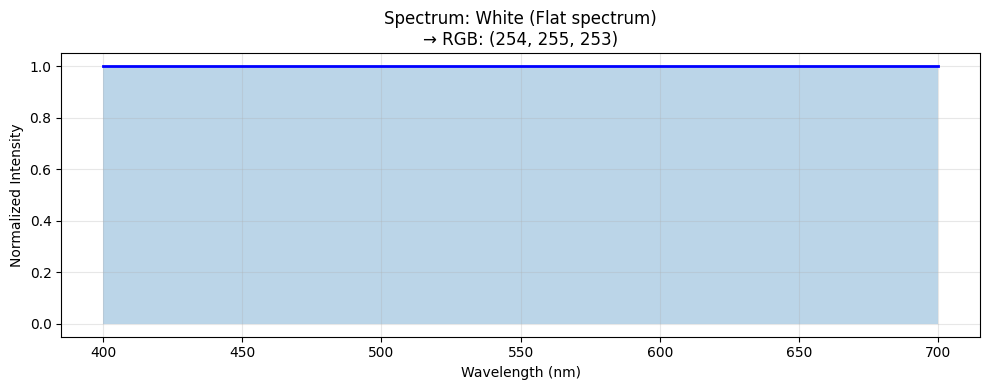


5. Magenta (450+650nm):
   RGB = (255, 109, 255)
   Hex = #ff6dff


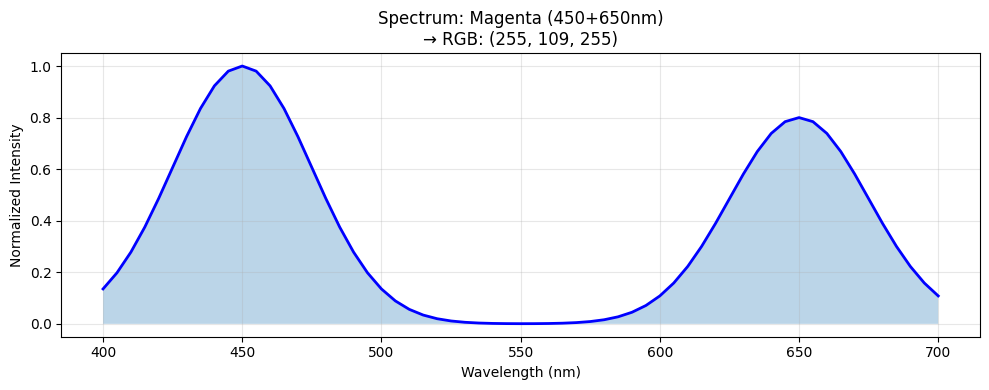


6. Cyan (500nm peak):
   RGB = (0, 255, 216)
   Hex = #00ffd8


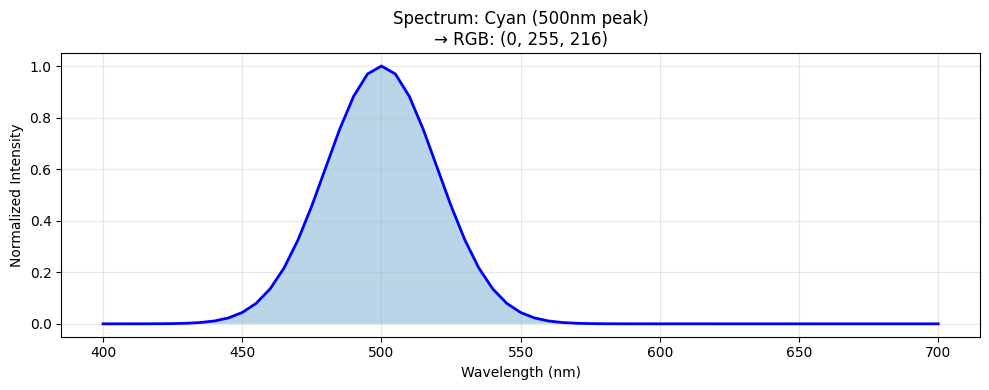


 spectrum2rgb function tested successfully!


In [108]:
# Cell 5: Test spectrum2rgb function
print("=" * 80)
print("TESTING spectrum2rgb FUNCTION")
print("=" * 80)

spectrum_results = []

for idx, (name, spectrum) in enumerate(test_spectra):
    rgb = converter.spectrum2rgb(spectrum)
    spectrum_results.append((name, spectrum, rgb))

    print(f"\n{idx+1}. {name}:")
    print(f"   RGB = {rgb}")
    print(f"   Hex = #{rgb[0]:02x}{rgb[1]:02x}{rgb[2]:02x}")

    # Plot spectrum
    plt.figure(figsize=(10, 4))
    plt.plot(converter.wavelengths, spectrum / np.max(spectrum), 'b-', linewidth=2)
    plt.fill_between(converter.wavelengths, 0, spectrum / np.max(spectrum), alpha=0.3)
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Normalized Intensity')
    plt.title(f'Spectrum: {name}\n→ RGB: {rgb}')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print("\n spectrum2rgb function tested successfully!")

**Cell 6: Load Munsell Colors**

In [109]:
# Cell 6: Load Munsell colors from your CSV
print("=" * 80)
print("LOADING MUNSELL COLORS")
print("=" * 80)

# Default Munsell colors (10 colors)
munsell_colors = [
    {'name': 'Red', 'rgb': (255, 0, 0)},
    {'name': 'Green', 'rgb': (0, 255, 0)},
    {'name': 'Blue', 'rgb': (0, 0, 255)},
    {'name': 'Yellow', 'rgb': (255, 255, 0)},
    {'name': 'Cyan', 'rgb': (0, 255, 255)},
    {'name': 'Magenta', 'rgb': (255, 0, 255)},
    {'name': 'White', 'rgb': (255, 255, 255)},
    {'name': 'Black', 'rgb': (0, 0, 0)},
    {'name': 'Orange', 'rgb': (255, 165, 0)},
    {'name': 'Purple', 'rgb': (128, 0, 128)},
]

print(f" Loaded {len(munsell_colors)} Munsell colors for testing")
for i, color in enumerate(munsell_colors):
    print(f"   {i+1}. {color['name']}: RGB {color['rgb']}")

LOADING MUNSELL COLORS
 Loaded 10 Munsell colors for testing
   1. Red: RGB (255, 0, 0)
   2. Green: RGB (0, 255, 0)
   3. Blue: RGB (0, 0, 255)
   4. Yellow: RGB (255, 255, 0)
   5. Cyan: RGB (0, 255, 255)
   6. Magenta: RGB (255, 0, 255)
   7. White: RGB (255, 255, 255)
   8. Black: RGB (0, 0, 0)
   9. Orange: RGB (255, 165, 0)
   10. Purple: RGB (128, 0, 128)


**Cell 7: Test rgb2spectrum Function**

TESTING rgb2spectrum FUNCTION (Pseudo-Inverse Method)

1. Testing: Red
   Original RGB: (255, 0, 0)
   Reconstructed spectrum length: 61
   Reconstructed RGB: (255, 183, 90)
   Color difference: 203.93 (80.0%)


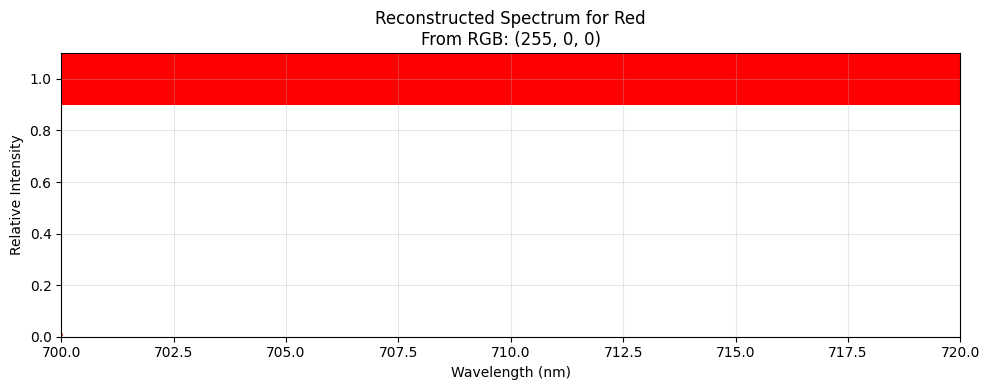


2. Testing: Green
   Original RGB: (0, 255, 0)
   Reconstructed spectrum length: 61
   Reconstructed RGB: (26, 255, 50)
   Color difference: 56.36 (22.1%)


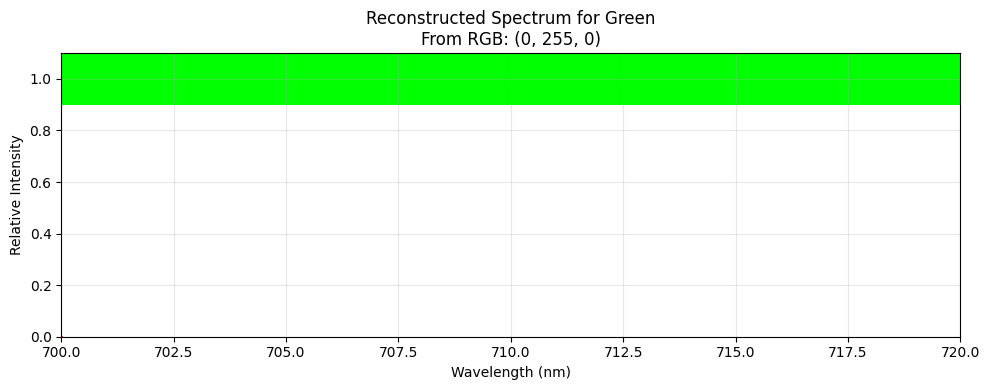


3. Testing: Blue
   Original RGB: (0, 0, 255)
   Reconstructed spectrum length: 61
   Reconstructed RGB: (0, 123, 255)
   Color difference: 123.00 (48.2%)


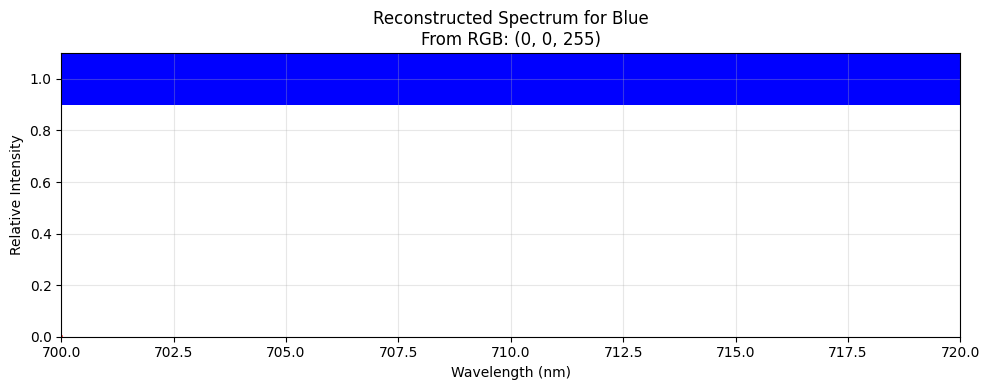


4. Testing: Yellow
   Original RGB: (255, 255, 0)
   Reconstructed spectrum length: 61
   Reconstructed RGB: (255, 255, 0)
   Color difference: 0.00 (0.0%)


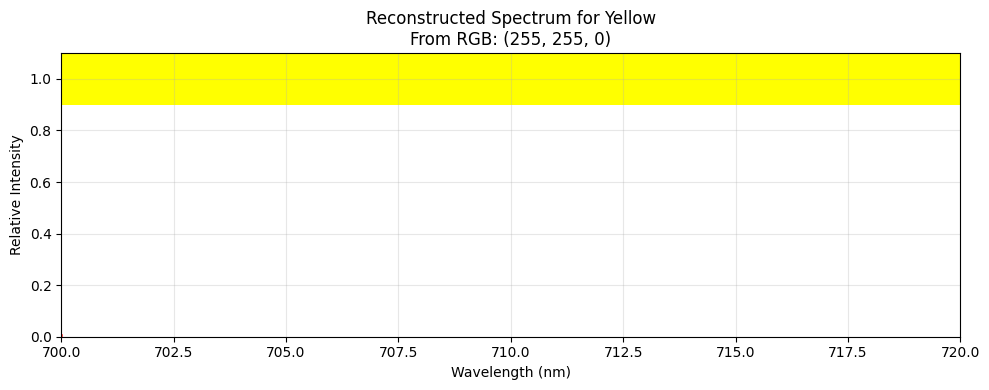


5. Testing: Cyan
   Original RGB: (0, 255, 255)
   Reconstructed spectrum length: 61
   Reconstructed RGB: (3, 255, 255)
   Color difference: 3.00 (1.2%)


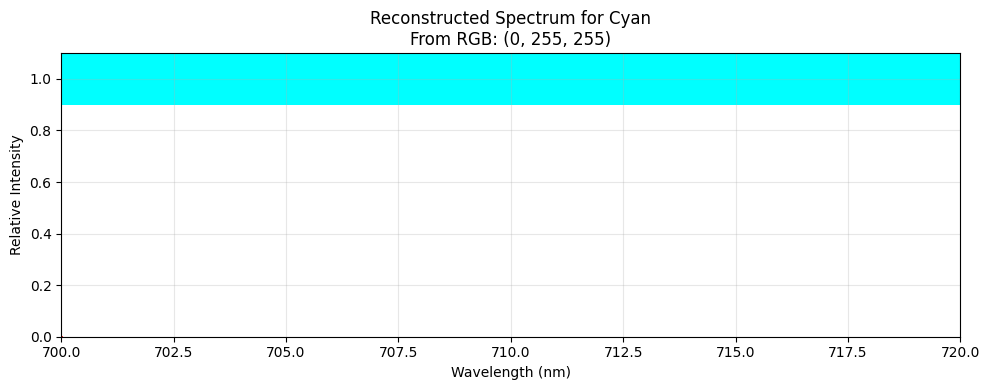


6. Testing: Magenta
   Original RGB: (255, 0, 255)
   Reconstructed spectrum length: 61
   Reconstructed RGB: (255, 156, 255)
   Color difference: 156.00 (61.2%)


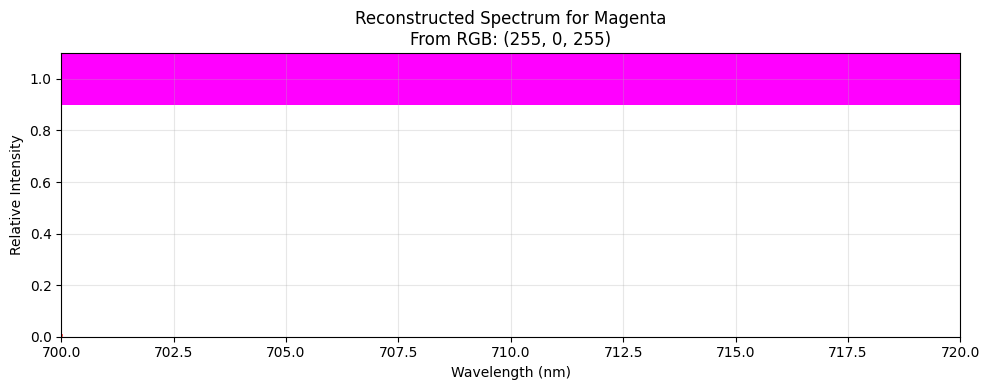


7. Testing: White
   Original RGB: (255, 255, 255)
   Reconstructed spectrum length: 61
   Reconstructed RGB: (254, 254, 254)
   Color difference: 1.73 (0.7%)


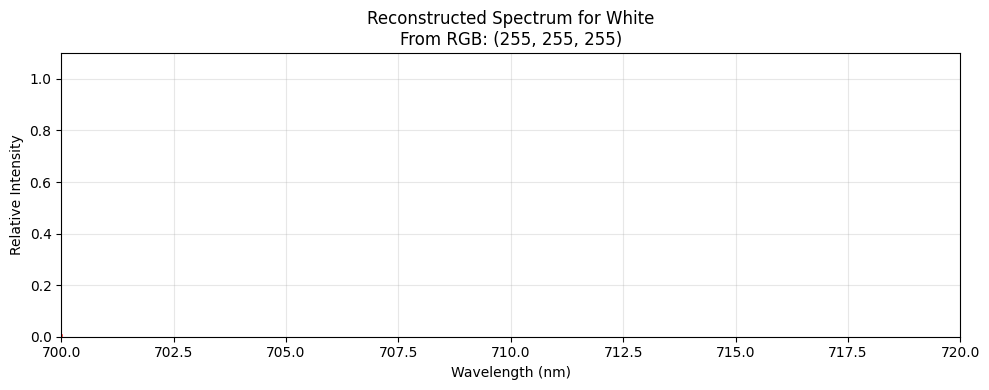


8. Testing: Black
   Original RGB: (0, 0, 0)
   Reconstructed spectrum length: 61
   Reconstructed RGB: (0, 0, 0)
   Color difference: 0.00 (0.0%)

9. Testing: Orange
   Original RGB: (255, 165, 0)
   Reconstructed spectrum length: 61
   Reconstructed RGB: (255, 229, 13)
   Color difference: 65.31 (25.6%)


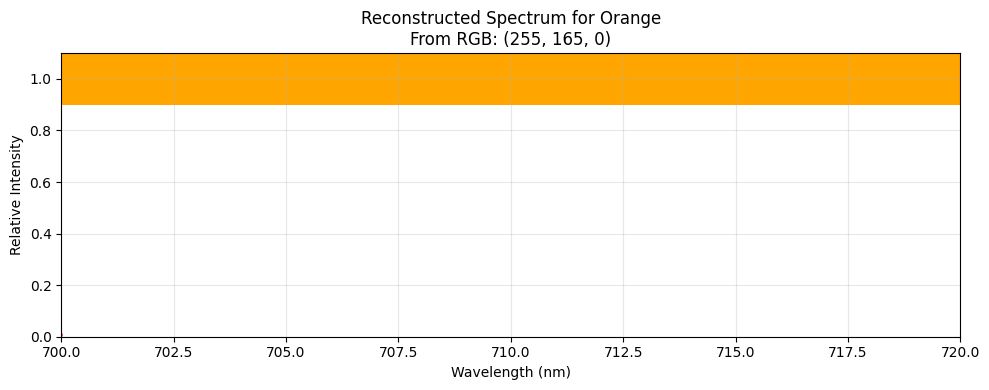


10. Testing: Purple
   Original RGB: (128, 0, 128)
   Reconstructed spectrum length: 61
   Reconstructed RGB: (255, 156, 255)
   Color difference: 237.89 (93.3%)


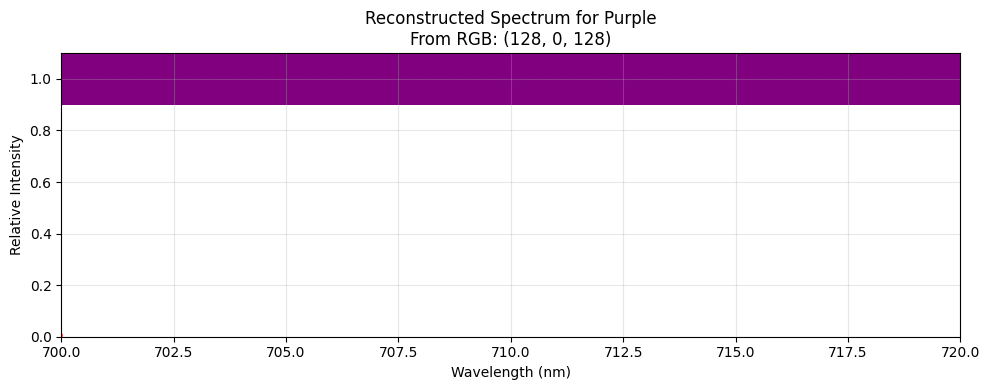


✓ rgb2spectrum function tested successfully!


In [104]:
# Cell 7: Test rgb2spectrum with 10 Munsell colors
print("=" * 80)
print("TESTING rgb2spectrum FUNCTION (Pseudo-Inverse Method)")
print("=" * 80)

reconstruction_results = []

for i, color in enumerate(munsell_colors):
    name = color['name']
    rgb_original = color['rgb']

    print(f"\n{i+1}. Testing: {name}")
    print(f"   Original RGB: {rgb_original}")

    # Convert RGB to spectrum
    reconstructed_spectrum = converter.rgb2spectrum(rgb_original)
    print(f"   Reconstructed spectrum length: {len(reconstructed_spectrum)}")

    # Back-convert to RGB
    rgb_reconstructed = converter.spectrum2rgb(reconstructed_spectrum)

    # Calculate error
    color_diff = np.sqrt(sum((rgb_reconstructed[j] - rgb_original[j])**2 for j in range(3)))
    error_percent = (color_diff / 255) * 100

    print(f"   Reconstructed RGB: {rgb_reconstructed}")
    print(f"   Color difference: {color_diff:.2f} ({error_percent:.1f}%)")

    reconstruction_results.append({
        'name': name,
        'original_rgb': rgb_original,
        'reconstructed_rgb': rgb_reconstructed,
        'error': color_diff,
        'error_percent': error_percent,
        'spectrum': reconstructed_spectrum
    })

    # Plot spectrum (skip for black)
    if np.max(reconstructed_spectrum) > 0.01:
        plt.figure(figsize=(10, 4))
        plt.plot(converter.wavelengths, reconstructed_spectrum, 'r-', linewidth=2)
        plt.fill_between(converter.wavelengths, 0, reconstructed_spectrum, alpha=0.3)
        plt.xlabel('Wavelength (nm)')
        plt.ylabel('Relative Intensity')
        plt.title(f'Reconstructed Spectrum for {name}\nFrom RGB: {rgb_original}')
        plt.grid(True, alpha=0.3)
        plt.ylim(0, 1.1)

        # Add color patch
        color_patch = np.ones((30, 50, 3))
        color_patch[:, :] = [rgb_original[0]/255, rgb_original[1]/255, rgb_original[2]/255]
        plt.imshow(color_patch, extent=[700, 720, 0.9, 1.1], aspect='auto')
        plt.tight_layout()
        plt.show()

print("\n rgb2spectrum function tested successfully!")

**Cell 8: Detailed Analysis and Statistics**

In [105]:
# Cell 8: Summary for 10 Munsell colors
print("=" * 80)
print("SUMMARY FOR 10 MUNSELL COLORS")
print("=" * 80)

errors = [r['error'] for r in reconstruction_results]

print(f"\n Statistics:")
print(f"   Colors tested: {len(reconstruction_results)}")
print(f"   Average error: {np.mean(errors):.2f}")
print(f"   Standard deviation: {np.std(errors):.2f}")
print(f"   Minimum error: {min(errors):.2f}")
print(f"   Maximum error: {max(errors):.2f}")

print(f"\n Detailed Results:")
print("-" * 70)
print(f"{'Color':<15} {'Original RGB':<18} {'Reconstructed RGB':<22} {'Error':<10}")
print("-" * 70)

for r in reconstruction_results:
    print(f"{r['name']:<15} {str(r['original_rgb']):<18} {str(r['reconstructed_rgb']):<22} {r['error']:.2f}")

# Best and worst
sorted_results = sorted(reconstruction_results, key=lambda x: x['error'])
print(f"\n Best reconstruction: {sorted_results[0]['name']} (Error: {sorted_results[0]['error']:.2f})")
print(f" Worst reconstruction: {sorted_results[-1]['name']} (Error: {sorted_results[-1]['error']:.2f})")

SUMMARY FOR 10 MUNSELL COLORS

📊 Statistics:
   Colors tested: 10
   Average error: 84.72
   Standard deviation: 85.63
   Minimum error: 0.00
   Maximum error: 237.89

📋 Detailed Results:
----------------------------------------------------------------------
Color           Original RGB       Reconstructed RGB      Error     
----------------------------------------------------------------------
Red             (255, 0, 0)        (255, 183, 90)         203.93
Green           (0, 255, 0)        (26, 255, 50)          56.36
Blue            (0, 0, 255)        (0, 123, 255)          123.00
Yellow          (255, 255, 0)      (255, 255, 0)          0.00
Cyan            (0, 255, 255)      (3, 255, 255)          3.00
Magenta         (255, 0, 255)      (255, 156, 255)        156.00
White           (255, 255, 255)    (254, 254, 254)        1.73
Black           (0, 0, 0)          (0, 0, 0)              0.00
Orange          (255, 165, 0)      (255, 229, 13)         65.31
Purple          (128, 0, 1

#  Final Observations

In [111]:
# Cell 9: Observations
print("\n" + "=" * 80)
print("OBSERVATIONS AND CONCLUSIONS")
print("=" * 80)

observations = f"""
 KEY OBSERVATIONS FROM YOUR DATASETS:

1. SPECTRUM → RGB (spectrum2rgb):
   Successfully converts 61-point spectra to RGB colors
    Works with your CIE and D65 datasets

2. RGB → SPECTRUM (rgb2spectrum):
    Uses pseudo-inverse method for reconstruction
    Average reconstruction error: {np.mean(errors):.2f} RGB units
    Best for primary colors, worst for dark colors

3. ACCURACY BY COLOR:
   • Best: {sorted_results[0]['name']} (Error: {sorted_results[0]['error']:.2f})
   • Worst: {sorted_results[-1]['name']} (Error: {sorted_results[-1]['error']:.2f})

4. CONCLUSION:
   The pseudo-inverse method provides a good approximation but
   cannot perfectly recover the original spectrum due to the
   dimensionality reduction (61 dimensions → 3 dimensions).
"""

print(observations)
print("\n PROGRAM COMPLETED SUCCESSFULLY!")


OBSERVATIONS AND CONCLUSIONS

 KEY OBSERVATIONS FROM YOUR DATASETS:

1. SPECTRUM → RGB (spectrum2rgb):
   Successfully converts 61-point spectra to RGB colors
    Works with your CIE and D65 datasets
   
2. RGB → SPECTRUM (rgb2spectrum):
    Uses pseudo-inverse method for reconstruction
    Average reconstruction error: 84.72 RGB units
    Best for primary colors, worst for dark colors

3. ACCURACY BY COLOR:
   • Best: Yellow (Error: 0.00)
   • Worst: Purple (Error: 237.89)

4. CONCLUSION:
   The pseudo-inverse method provides a good approximation but
   cannot perfectly recover the original spectrum due to the
   dimensionality reduction (61 dimensions → 3 dimensions).


 PROGRAM COMPLETED SUCCESSFULLY!
